### Install dependencies and import libraries

In [1]:
import pandas as pd
import numpy as np
import boto3
import json
import matplotlib.pyplot as plt
from botocore.exceptions import ClientError
from datetime import datetime as dt

import urllib.parse
import hashlib
import hmac
import base64

import time

import requests
import json

In [109]:
PATH = "static_training_data/XBTUSDC_60.csv"
btc_df = pd.read_csv(PATH, names=['time','open','high','low','close','volume','trades'])
btc_df['datetime'] = btc_df['time'].apply(lambda x: dt.utcfromtimestamp(x))
btc_df = btc_df.set_index('datetime')

# Create a full range of hourly timestamps based on the min and max datetime in the existing data
full_range = pd.date_range(start=btc_df.index.min(), end=btc_df.index.max(), freq='h')

# Reindex the DataFrame with the full hourly range, filling in NaN for missing rows
btc_df = btc_df.reindex(full_range)

# We want to perform the following for the null values:
# - volume and trades goes to zero
# - for closed we want to ffill
# - open, high, and low will be the value for closed
# Create a new column for each of open, high, low, and closed that is the previous value
for zero_col in ['volume','trades']:
    btc_df[zero_col] = btc_df[zero_col].fillna(0)

# forward fill closed
btc_df['close'] = btc_df['close'].fillna(method='ffill')

# now for open, high, and low, replace the values with close if they are na
for col in ['open','high','low']:
    #btc_df[col] = btc_df.apply(lambda x: x[col] if x[col] != np.nan else x['close'], axis=1)
    btc_df[col] = btc_df[col].fillna(btc_df['close'])
# Optional: reset the index and rename the index column to 'datetime' for consistency
#df_full = df_full.reset_index().rename(columns={'index': 'datetime'})

btc_df = btc_df.drop(columns='time')

btc_df['close_diff_1h'] = btc_df['close'].diff()
btc_df['close_diff_24h'] = btc_df['close'].diff(periods=24)
btc_df['close_diff_7d'] = btc_df['close'].diff(periods=24*7)
print(btc_df.shape)
btc_df.head(7)

(41457, 9)


/tmp/ipykernel_126/4172623024.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  btc_df['close'] = btc_df['close'].fillna(method='ffill')


,open,high,low,close,volume,trades,close_diff_1h,close_diff_24h,close_diff_7d
2020-01-08 15:00:00,8300.00,8300.00,8300.00,8300.00,0.002410,2.0,NaN,NaN,NaN
2020-01-08 16:00:00,8217.51,8217.51,8217.51,8217.51,0.012290,2.0,-82.49,NaN,NaN
2020-01-08 17:00:00,7900.01,7949.99,7870.00,7949.99,0.052487,10.0,-267.52,NaN,NaN
2020-01-08 18:00:00,7949.99,8000.00,7870.99,7870.99,0.038592,8.0,-79.00,NaN,NaN
2020-01-08 19:00:00,7870.99,7870.99,7870.99,7870.99,0.000000,0.0,0.00,NaN,NaN
2020-01-08 20:00:00,7870.98,7999.99,7870.00,7999.99,0.044715,5.0,129.00,NaN,NaN
2020-01-08 21:00:00,7999.99,7999.99,7999.99,7999.99,0.000000,0.0,0.00,NaN,NaN


In [110]:
btc_df.describe(include='all')

,open,high,low,close,volume,trades,close_diff_1h,close_diff_24h,close_diff_7d
count,41457.000000,41457.000000,41457.000000,41457.000000,41457.000000,41457.000000,41456.000000,41433.000000,41289.000000
mean,33899.487127,34027.776069,33765.801826,33902.963737,4.068348,69.503679,1.326018,32.448482,230.049311
std,18207.176685,18280.790485,18131.440736,18210.213806,10.196301,117.851120,264.327960,1265.366231,3302.429228
min,4183.300000,4525.880000,3999.560000,4246.520000,0.000000,0.000000,-3518.800000,-11176.920000,-21320.210000
25%,19303.350000,19351.600000,19234.560000,19299.320000,0.316790,18.000000,-69.232500,-373.660000,-975.960000
50%,30311.510000,30376.150000,30248.860000,30317.650000,1.374726,43.000000,0.000000,22.190000,140.900000
75%,47335.320000,47540.550000,47120.120000,47335.740000,4.159852,84.000000,75.372500,450.650000,1542.040000
max,73565.970000,73777.000000,73290.920000,73529.350000,398.704372,6115.000000,4051.840000,9032.990000,14596.790000


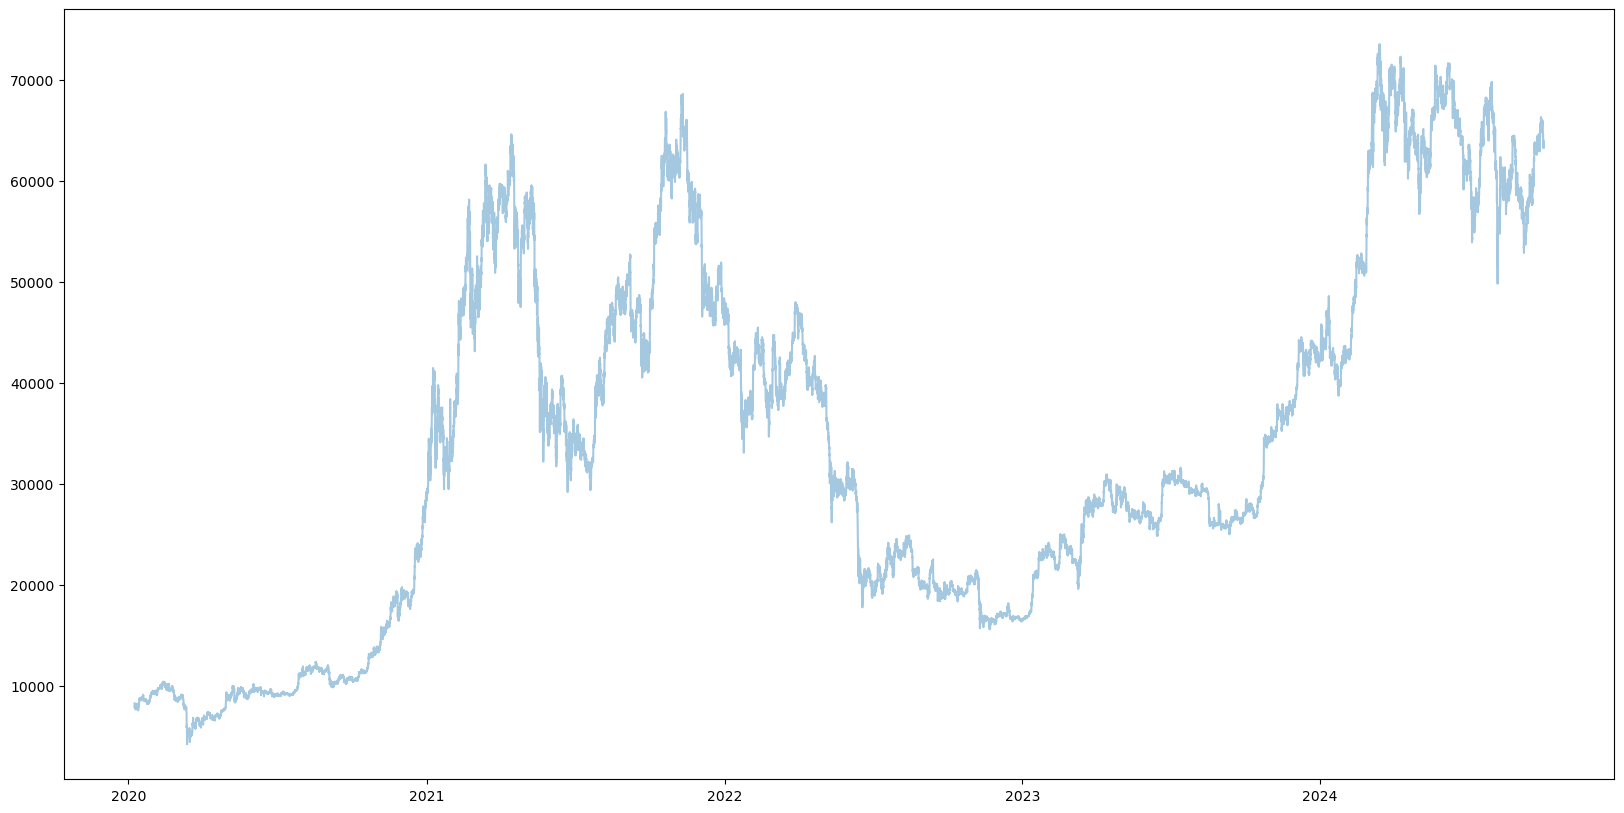

In [111]:
fig, axs = plt.subplots(figsize=(20,10))

axs.plot(
    btc_df.index,
    btc_df['close'],
    alpha=0.4
)


(-200.0, 200.0)

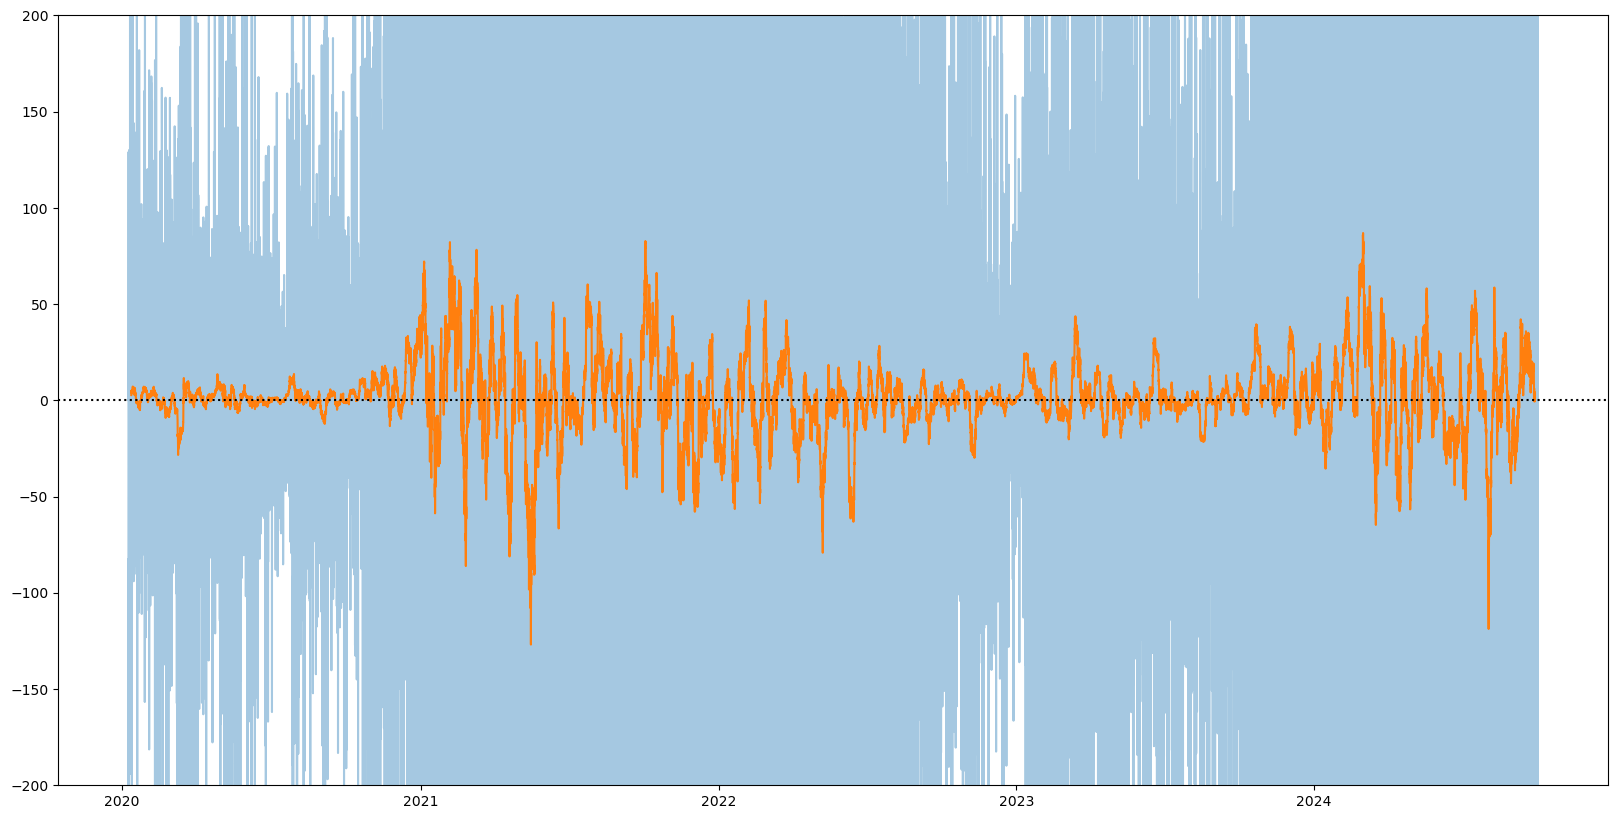

In [120]:
fig, axs = plt.subplots(figsize=(20,10))

axs.plot(
    btc_df.index,
    btc_df['close_diff_1h'],
    alpha=0.4
)
axs.plot(
    btc_df.index,
    btc_df['close_diff_1h'].rolling(24*7, center=True).mean(),
)
axs.axhline(
    0,
    color='black',
    ls=':'
)
axs.set_ylim(-200,200)

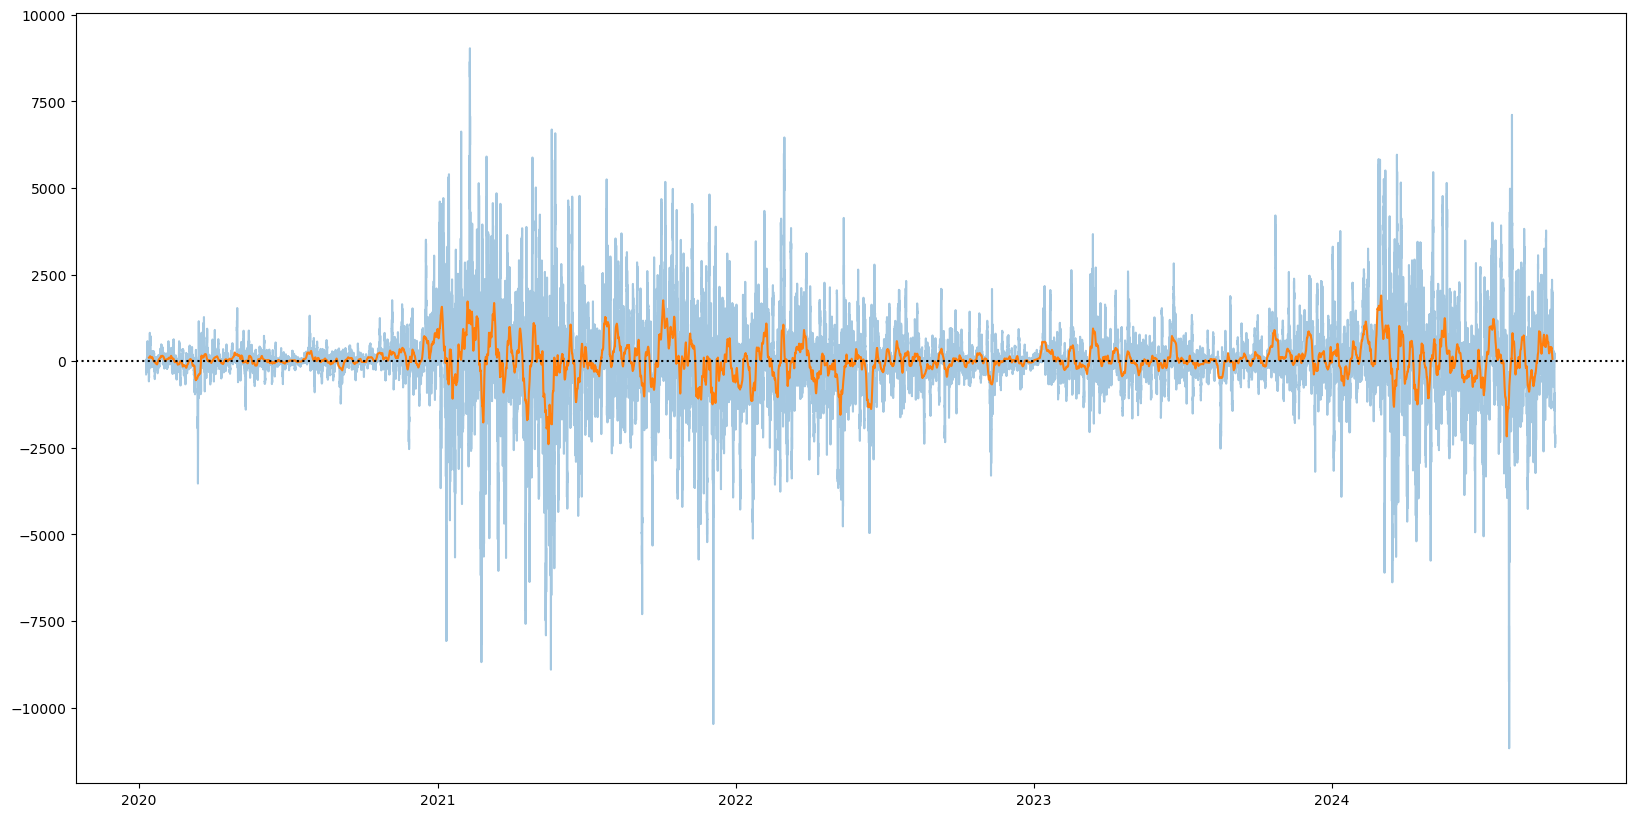

In [119]:
fig, axs = plt.subplots(figsize=(20,10))

axs.plot(
    btc_df.index,
    btc_df['close_diff_24h'],
    alpha=0.4
)
axs.plot(
    btc_df.index,
    btc_df['close_diff_24h'].rolling(24*7, center=True).mean(),
)

axs.axhline(
    0,
    color='black',
    ls=':'
)

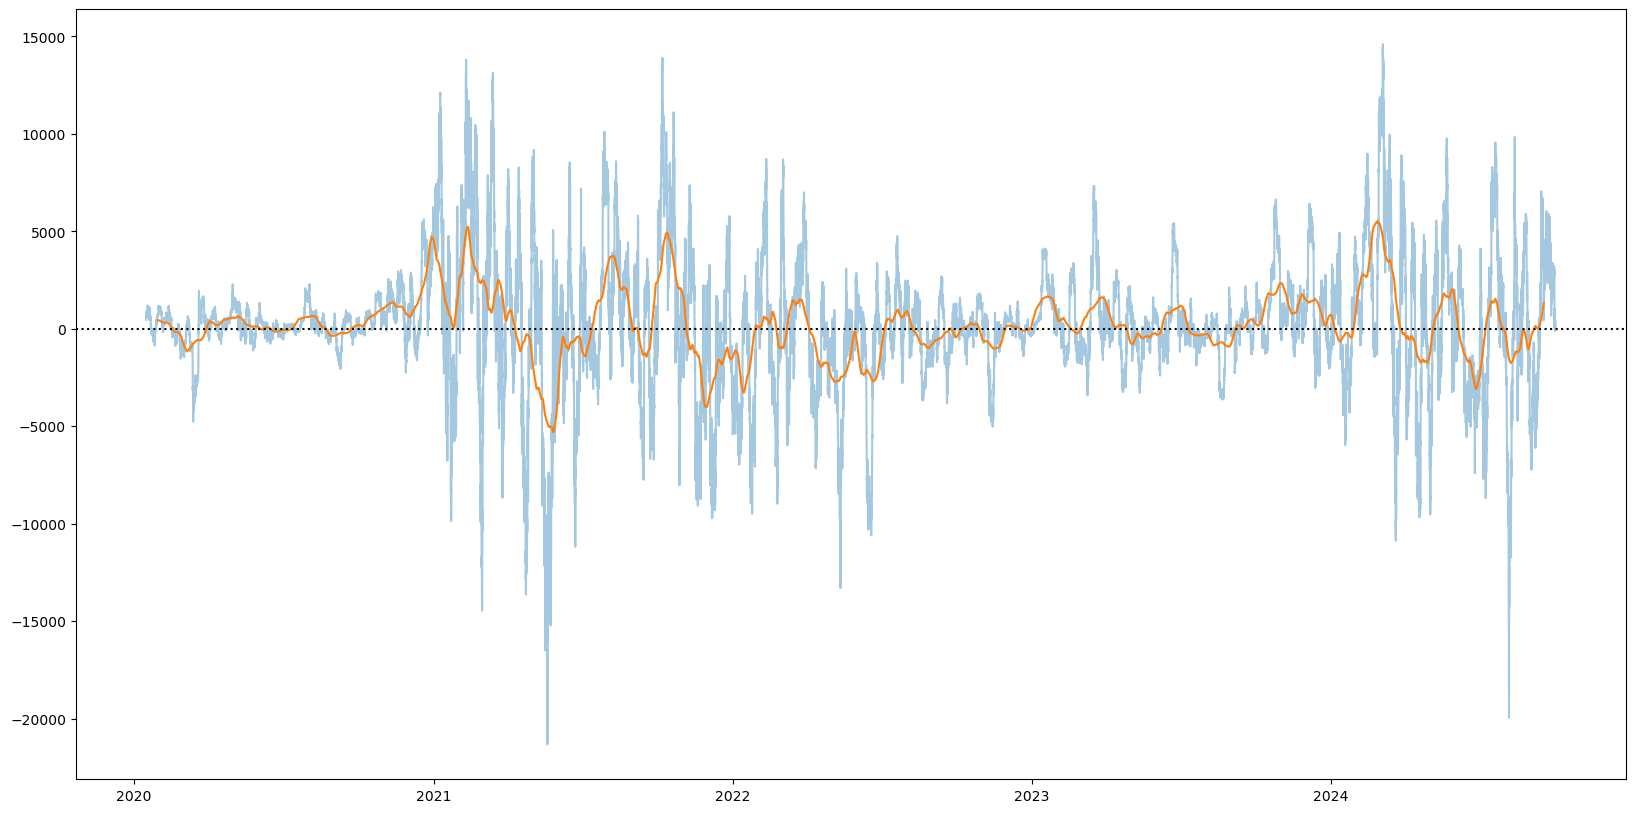

In [118]:
fig, axs = plt.subplots(figsize=(20,10))

axs.plot(
    btc_df.index,
    btc_df['close_diff_7d'],
    alpha=0.4
)
axs.plot(
    btc_df.index,
    btc_df['close_diff_7d'].rolling(24*7*4, center=True).mean(),
)

axs.axhline(
    0,
    color='black',
    ls=':'
)

(0.0, 75.0)

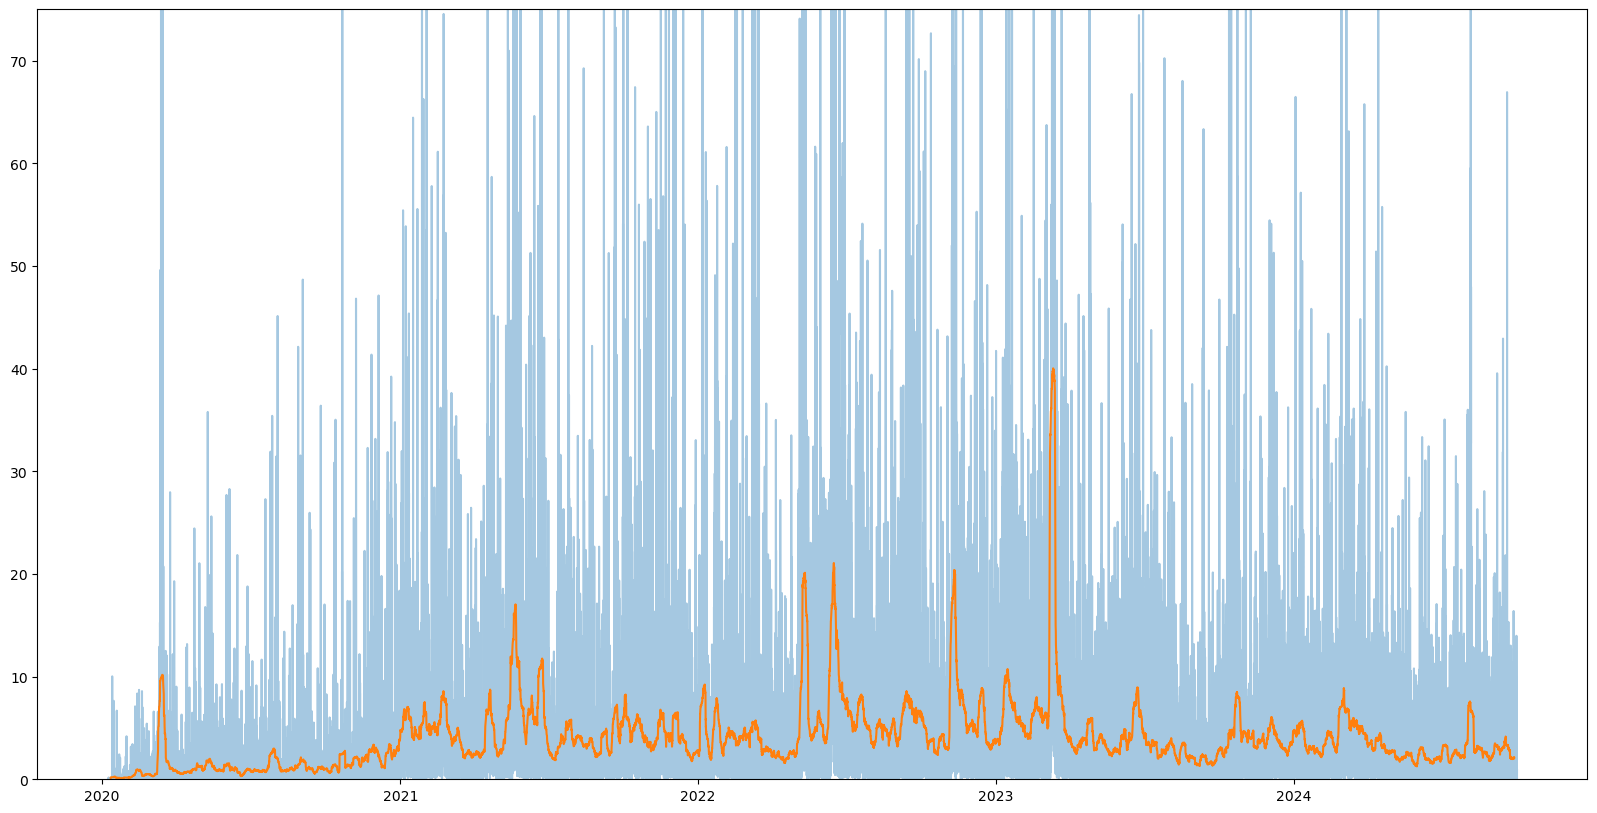

In [101]:
fig, axs = plt.subplots(figsize=(20,10))
axs.plot(
    btc_df.index,
    btc_df['volume'],
    alpha=0.4
)

axs.plot(
    btc_df.index,
    btc_df['volume'].rolling(24*7, center=True).mean(),
)

axs.set_ylim(0,75)

(0.0, 1000.0)

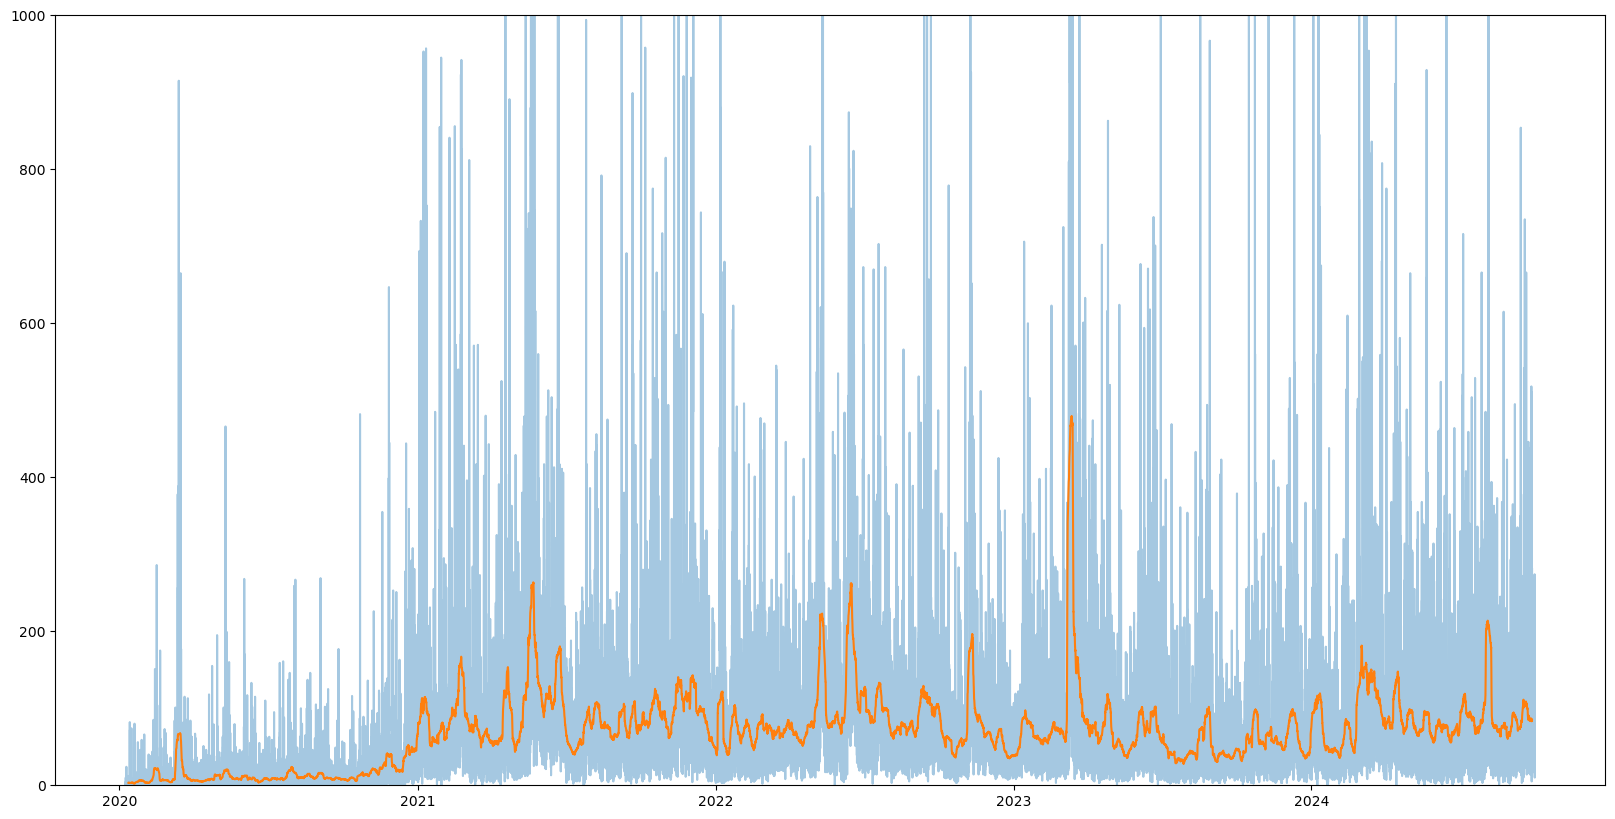

In [99]:
fig, axs = plt.subplots(figsize=(20,10))
axs.plot(
    btc_df.index,
    btc_df['trades'],
    alpha=0.4
)

axs.plot(
    btc_df.index,
    btc_df['trades'].rolling(24*7, center=True).mean(),
)

axs.set_ylim(0,1000)

In [67]:
# Obtain credentials

def get_secret():

    secret_name = "gozer"
    region_name = "us-east-2"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        # For a list of exceptions thrown, see
        # https://docs.aws.amazon.com/secretsmanager/latest/apireference/API_GetSecretValue.html
        raise e

    secret = get_secret_value_response['SecretString']

    return json.loads(secret)

secret = get_secret()


In [68]:
secret.keys()

dict_keys(['api_key', 'private_key'])

### Obtain data from API

In [69]:
import requests
url_prefix = "https://api.kraken.com"

url = "0/public/OHLC?pair=XBTUSD"

payload = {}
headers = {
  'Accept': 'application/json'
}

response = requests.request("GET", f"{url_prefix}/{url}", headers=headers, data=payload)

response_text = json.loads(response.text)

response_text.keys()

dict_keys(['error', 'result'])

In [70]:
response_text['result'].keys()

dict_keys(['XXBTZUSD', 'last'])

In [71]:
response_text['result']['XXBTZUSD'][0:2]

[[1731986220,
  '91284.0',
  '91284.0',
  '91283.9',
  '91283.9',
  '91283.9',
  '0.01886563',
  7],
 [1731986280,
  '91284.0',
  '91284.0',
  '91283.9',
  '91284.0',
  '91283.9',
  '0.35395611',
  17]]

In [87]:
Kraken_secret_key = secret['private_key']

Kraken_headers ={

'API-Key': secret['api_key'] 

}

def Kraken_account_balance(Kraken_headers):

    URI_path= '/0/private/Balance'

    URL_path = 'https://api.kraken.com/0/private/Balance'

    Kraken_nonce = str(int(time.time()*1000))

    Kraken_POST_data = {

        'nonce': Kraken_nonce
    }

    url_encoded_post_data = urllib.parse.urlencode(Kraken_POST_data)
    encoded = (str(Kraken_POST_data['nonce'])+url_encoded_post_data).encode()
    message = URI_path.encode() + hashlib.sha256(encoded).digest() 
    Kraken_signature = hmac.new(
        base64.b64decode(Kraken_secret_key),
        message,
        hashlib.sha512
    )

    Kraken_signature_digest = base64.b64encode(Kraken_signature.digest())

    Kraken_headers['API-Sign'] = Kraken_signature_digest.decode()

    response = requests.post(
        URL_path,
        data=Kraken_POST_data,
        headers=Kraken_headers
    )

    return response.json()

Kraken_account_balance(Kraken_headers)

nonce=1732033013831
b'/0/private/Balance\xe6,8\x84|(\xaf\x85\x08<d!\xa5\xc1\xf4Ng\xd2c\xe2\xbdS~`H\xf1\xda!\xf3\xb4\xa8\xa1'


{'error': [], 'result': {'ZUSD': '100.0000'}}